TX exists? True C:\Users\lawre\Downloads\transactions_data.csv
PR exists? True C:\Users\lawre\Downloads\products_data.csv
CU exists? True C:\Users\lawre\Downloads\customers_data (1).csv
Loaded shapes: {'tx': (10000, 8), 'pr': (20, 3), 'cu': (100, 4)}
Shapes: {'tx': (10000, 7), 'pr': (20, 3), 'cu': (100, 4), 'merged': (20837, 12)}


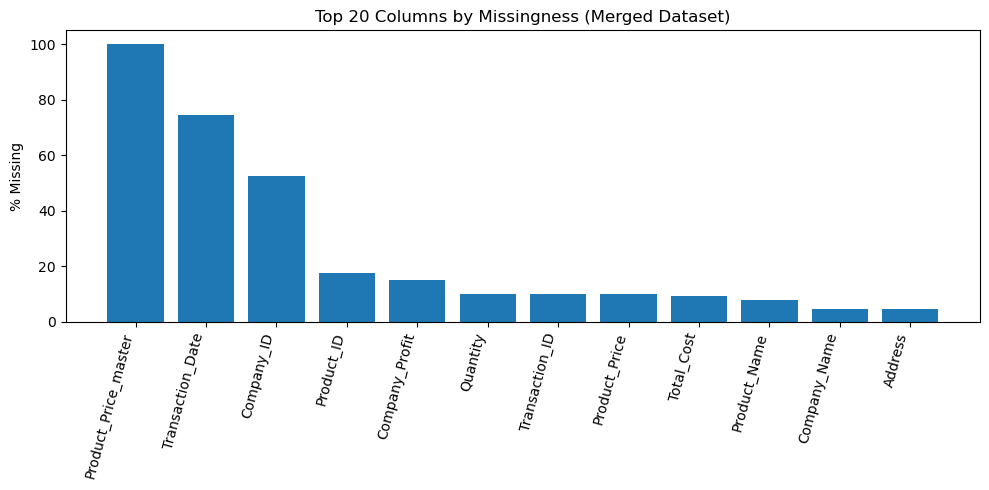

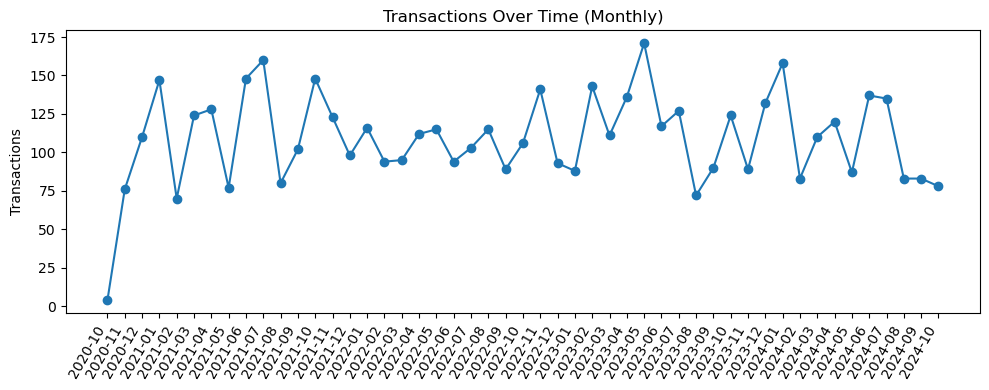

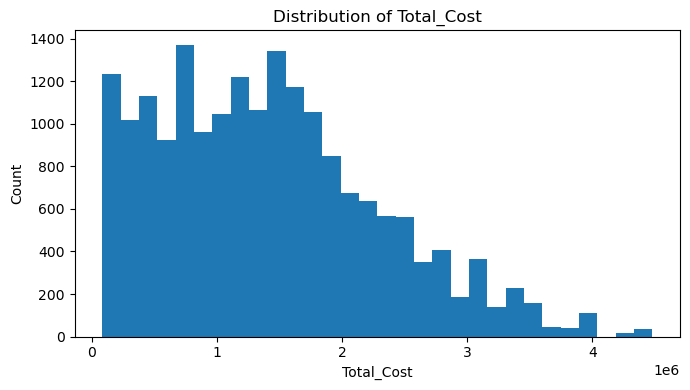

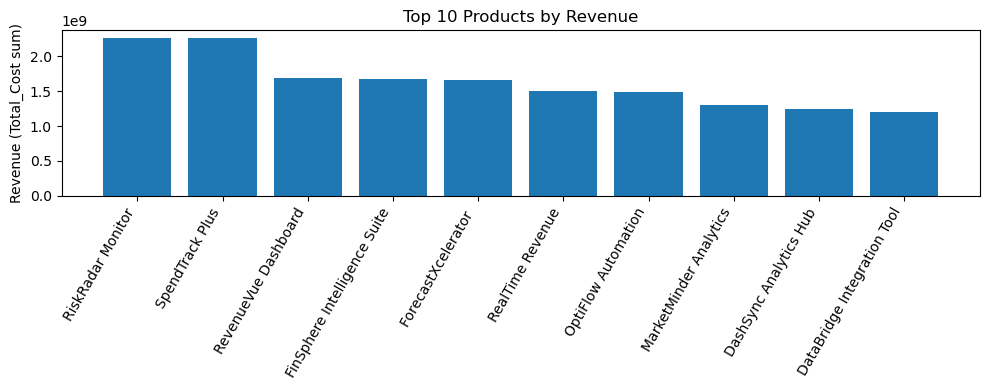

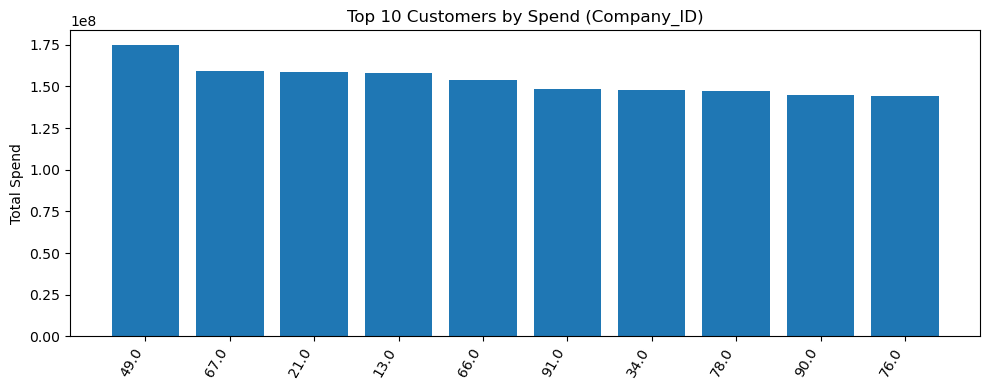


Cutoff: 2023-10-27 00:00:00
Dataset shape (customers): (100, 16)


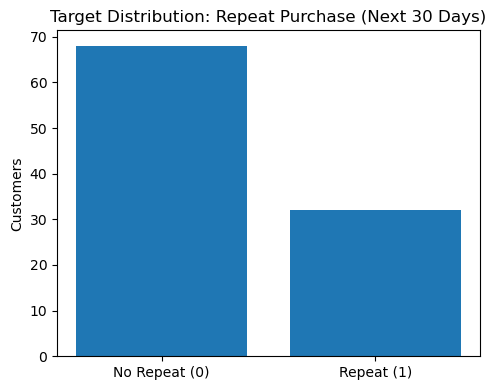

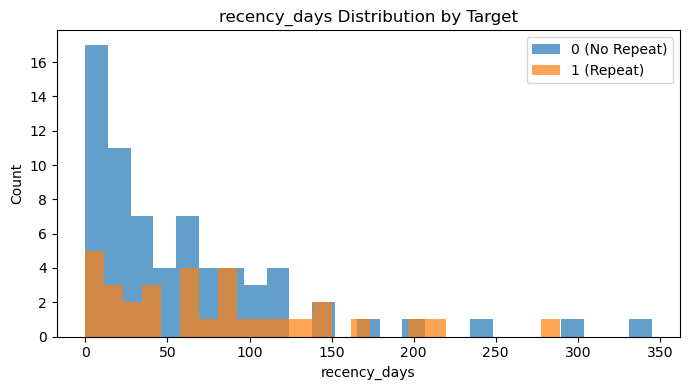

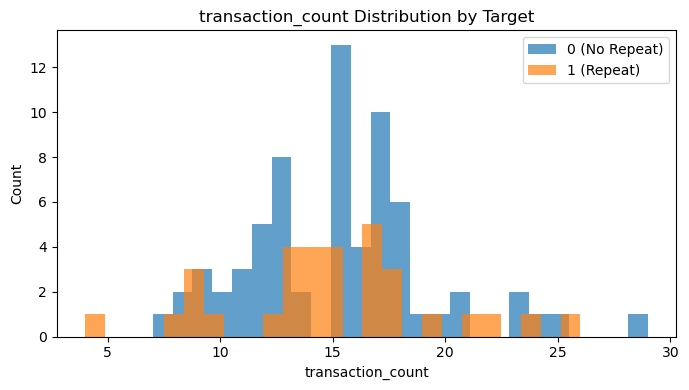

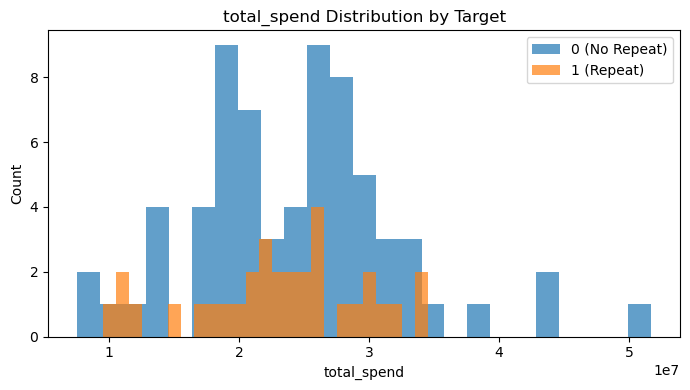

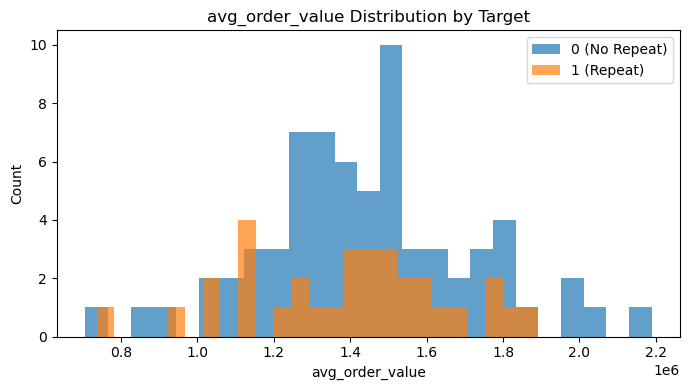

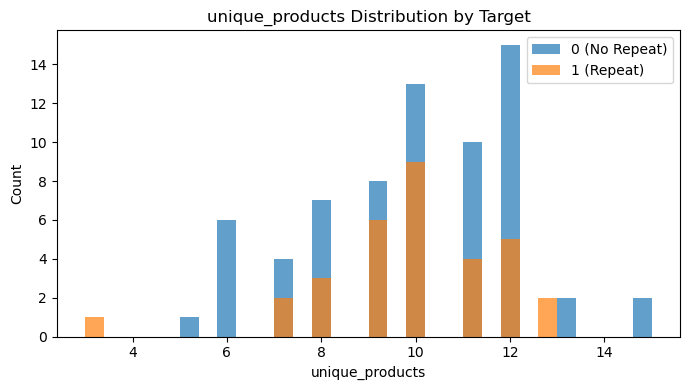

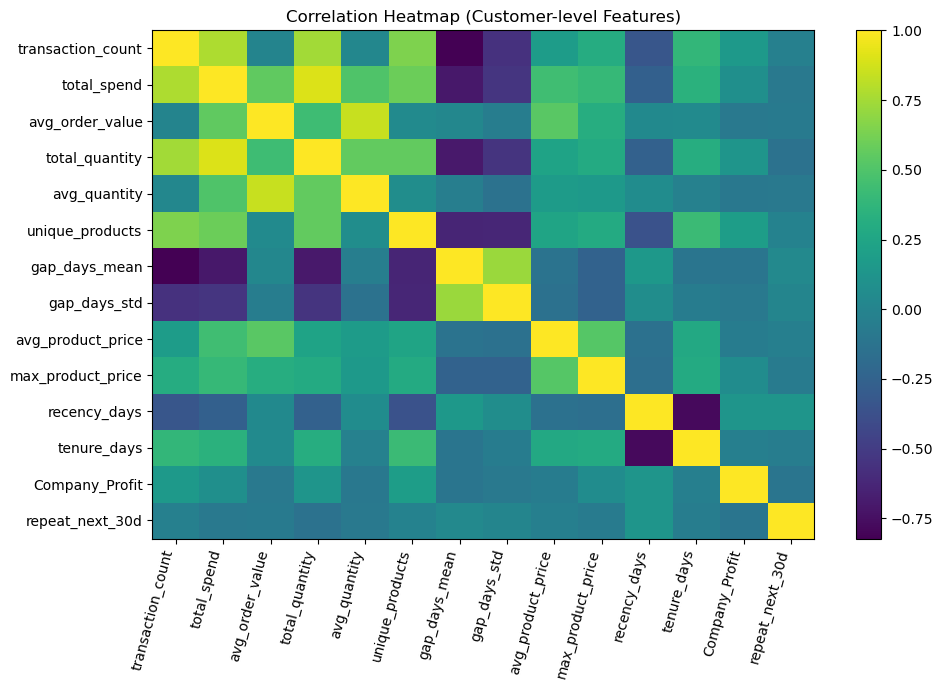


ROC-AUC: 0.5367647058823529


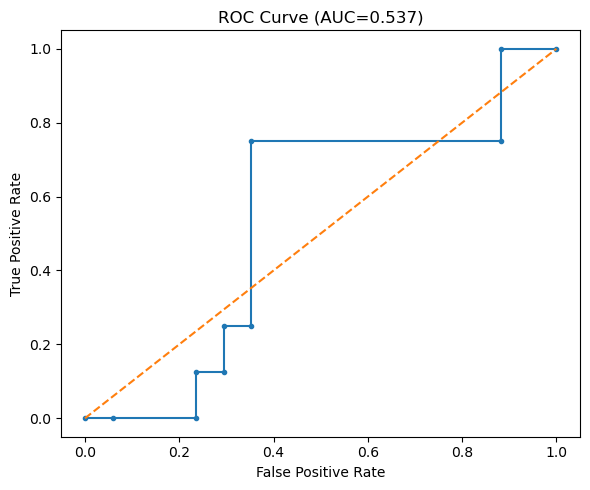

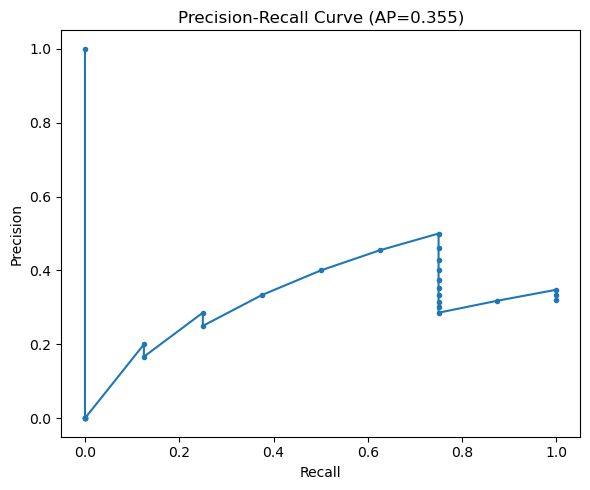

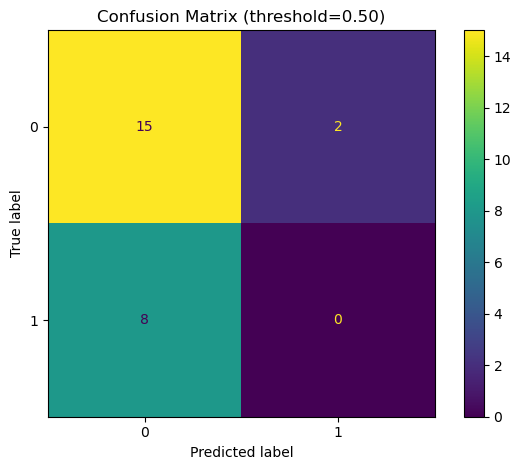

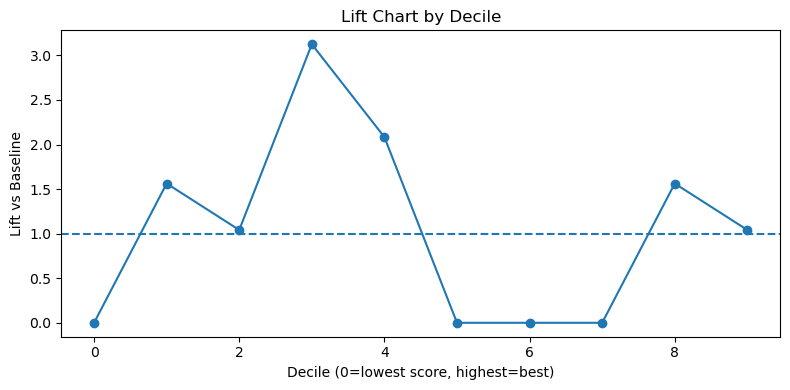

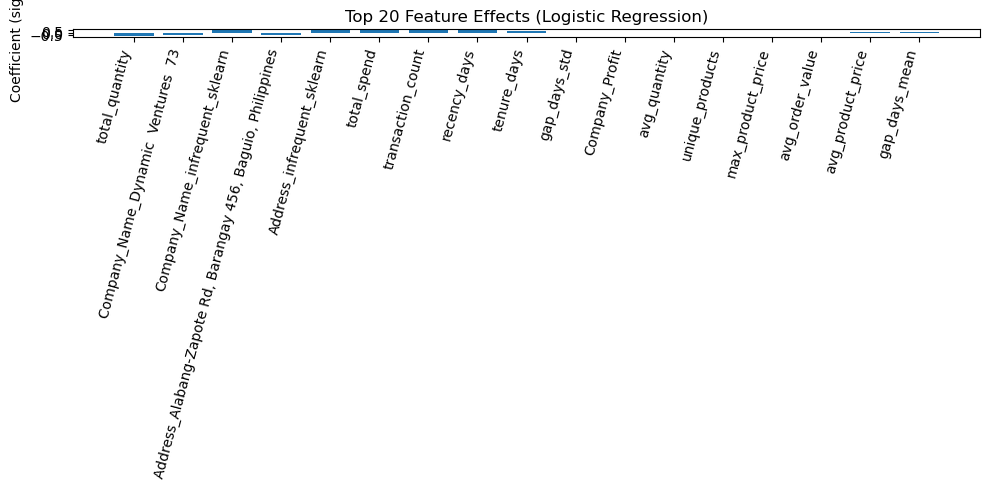


Top feature coefficients (absolute):
total_quantity                                                 -0.809623
Company_Name_Dynamic  Ventures  73                             -0.635892
Company_Name_infrequent_sklearn                                 0.635188
Address_Alabang-Zapote Rd, Barangay 456, Baguio, Philippines   -0.604975
Address_infrequent_sklearn                                      0.604270
total_spend                                                     0.540911
transaction_count                                               0.467883
recency_days                                                    0.465302
tenure_days                                                     0.267555
gap_days_std                                                   -0.169496
Company_Profit                                                 -0.144733
avg_quantity                                                   -0.135305
unique_products                                                -0.123386
max_product_p

In [48]:
# ============================================================
# VISUALIZE EVERYTHING: Integrated 3-table repeat-purchase model
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)

# -----------------------------
# 1) Load data (FIXED PATHS)
# -----------------------------
TX_PATH = r"C:\Users\lawre\Downloads\transactions_data.csv"
PR_PATH = r"C:\Users\lawre\Downloads\products_data.csv"
CU_PATH = r"C:\Users\lawre\Downloads\customers_data (1).csv"

# Quick path checks (helps you immediately)
print("TX exists?", os.path.exists(TX_PATH), TX_PATH)
print("PR exists?", os.path.exists(PR_PATH), PR_PATH)
print("CU exists?", os.path.exists(CU_PATH), CU_PATH)

missing = [p for p in [TX_PATH, PR_PATH, CU_PATH] if not os.path.exists(p)]
if missing:
    raise FileNotFoundError("Missing file(s):\n" + "\n".join(missing))

tx = pd.read_csv(TX_PATH)
pr = pd.read_csv(PR_PATH)
cu = pd.read_csv(CU_PATH)

print("Loaded shapes:", {"tx": tx.shape, "pr": pr.shape, "cu": cu.shape})

# -----------------------------
# 2) Clean data
# -----------------------------
tx = tx.loc[:, ~tx.columns.str.contains("^Unnamed", case=False)].copy()

# Safer: only parse if column exists
if "Transaction_Date" in tx.columns:
    tx["Transaction_Date"] = pd.to_datetime(tx["Transaction_Date"], errors="coerce")
else:
    raise KeyError("transactions_data.csv must contain a 'Transaction_Date' column.")

for c in ["Transaction_ID", "Company_ID", "Product_ID", "Quantity"]:
    if c in tx.columns:
        tx[c] = pd.to_numeric(tx[c], errors="coerce")

for c in ["Product_Price", "Total_Cost"]:
    if c in tx.columns:
        tx[c] = pd.to_numeric(tx[c], errors="coerce")

pr = pr.copy()
if "Product_ID" not in pr.columns:
    raise KeyError("products_data.csv must contain a 'Product_ID' column.")
pr["Product_ID"] = pd.to_numeric(pr["Product_ID"], errors="coerce")

# Keep master product price separately if present
if "Product_Price" in pr.columns:
    pr["Product_Price_master"] = pd.to_numeric(pr["Product_Price"], errors="coerce")
    pr = pr.drop(columns=["Product_Price"], errors="ignore")

cu = cu.copy()
if "Company_ID" not in cu.columns:
    raise KeyError("customers_data.csv must contain a 'Company_ID' column.")
cu["Company_ID"] = pd.to_numeric(cu["Company_ID"], errors="coerce")

if "Company_Profit" in cu.columns:
    cu["Company_Profit"] = pd.to_numeric(cu["Company_Profit"], errors="coerce")

for c in ["Company_Name", "Address"]:
    if c in cu.columns:
        cu[c] = cu[c].astype(str).replace({"nan": np.nan, "None": np.nan})

# -----------------------------
# 3) MERGE / JOIN (core fix)
# -----------------------------
# Ensure keys exist in transactions
if "Product_ID" not in tx.columns or "Company_ID" not in tx.columns:
    raise KeyError("transactions_data.csv must contain both 'Product_ID' and 'Company_ID' columns.")

df = (
    tx.merge(pr, on="Product_ID", how="left")
      .merge(cu, on="Company_ID", how="left")
)

print("Shapes:", {"tx": tx.shape, "pr": pr.shape, "cu": cu.shape, "merged": df.shape})

# ============================================================
# A) VISUALIZE RAW + MERGED DATA (EDA visuals)
# ============================================================

# --- A1) Missingness bar chart (top 20)
missing = (df.isna().mean().sort_values(ascending=False) * 100).head(20)

plt.figure(figsize=(10, 5))
plt.bar(missing.index.astype(str), missing.values)
plt.xticks(rotation=75, ha="right")
plt.ylabel("% Missing")
plt.title("Top 20 Columns by Missingness (Merged Dataset)")
plt.tight_layout()
plt.show()

# --- A2) Transaction timeline (# tx per month)
df_dates = df.dropna(subset=["Transaction_Date"]).copy()
if not df_dates.empty:
    df_dates["YearMonth"] = df_dates["Transaction_Date"].dt.to_period("M").astype(str)
    monthly = df_dates.groupby("YearMonth").size()

    plt.figure(figsize=(10, 4))
    plt.plot(monthly.index, monthly.values, marker="o")
    plt.xticks(rotation=60, ha="right")
    plt.ylabel("Transactions")
    plt.title("Transactions Over Time (Monthly)")
    plt.tight_layout()
    plt.show()
else:
    print("No valid Transaction_Date rows to plot timeline.")

# --- A3) Total Cost distribution
if "Total_Cost" in df.columns:
    df_cost = df.dropna(subset=["Total_Cost"]).copy()
    if not df_cost.empty:
        plt.figure(figsize=(7, 4))
        plt.hist(df_cost["Total_Cost"], bins=30)
        plt.xlabel("Total_Cost")
        plt.ylabel("Count")
        plt.title("Distribution of Total_Cost")
        plt.tight_layout()
        plt.show()
    else:
        print("No valid Total_Cost to plot.")
else:
    print("Column 'Total_Cost' not found. Skipping A3.")

# --- A4) Top 10 products by revenue
if "Product_Name" in df.columns and "Total_Cost" in df.columns:
    top_prod = (df.dropna(subset=["Product_Name", "Total_Cost"])
                  .groupby("Product_Name")["Total_Cost"].sum()
                  .sort_values(ascending=False)
                  .head(10))
    if not top_prod.empty:
        plt.figure(figsize=(10, 4))
        plt.bar(top_prod.index.astype(str), top_prod.values)
        plt.xticks(rotation=60, ha="right")
        plt.ylabel("Revenue (Total_Cost sum)")
        plt.title("Top 10 Products by Revenue")
        plt.tight_layout()
        plt.show()
else:
    print("Skipping A4 (need Product_Name and Total_Cost).")

# --- A5) Top 10 customers by total spend
if "Company_ID" in df.columns and "Total_Cost" in df.columns:
    top_cust = (df.dropna(subset=["Company_ID", "Total_Cost"])
                  .groupby("Company_ID")["Total_Cost"].sum()
                  .sort_values(ascending=False)
                  .head(10))
    if not top_cust.empty:
        plt.figure(figsize=(10, 4))
        plt.bar(top_cust.index.astype(str), top_cust.values)
        plt.xticks(rotation=60, ha="right")
        plt.ylabel("Total Spend")
        plt.title("Top 10 Customers by Spend (Company_ID)")
        plt.tight_layout()
        plt.show()
else:
    print("Skipping A5 (need Company_ID and Total_Cost).")

# ============================================================
# B) BUILD CUSTOMER-LEVEL DATASET + TARGET (repeat next 30 days)
# ============================================================

needed_cols = ["Company_ID", "Transaction_Date", "Total_Cost"]
for col in needed_cols:
    if col not in df.columns:
        raise KeyError(f"Missing required column for modeling: {col}")

df_model = df.dropna(subset=needed_cols).copy()
if df_model.empty:
    raise ValueError("No usable rows after filtering. Check missing Transaction_Date/Total_Cost.")

cutoff = df_model["Transaction_Date"].quantile(0.75)
history = df_model[df_model["Transaction_Date"] <= cutoff].copy()
future_window = df_model[
    (df_model["Transaction_Date"] > cutoff) &
    (df_model["Transaction_Date"] <= cutoff + pd.Timedelta(days=30))
].copy()

history = history.sort_values(["Company_ID", "Transaction_Date"])
history["prev_date"] = history.groupby("Company_ID")["Transaction_Date"].shift(1)
history["gap_days"] = (history["Transaction_Date"] - history["prev_date"]).dt.days

# Use Product_Price if present; else fallback to Product_Price_master; else skip
price_col = None
if "Product_Price" in history.columns:
    price_col = "Product_Price"
elif "Product_Price_master" in history.columns:
    price_col = "Product_Price_master"

agg_dict = {
    "transaction_count": ("Transaction_ID", "count") if "Transaction_ID" in history.columns else ("Total_Cost", "size"),
    "total_spend": ("Total_Cost", "sum"),
    "avg_order_value": ("Total_Cost", "mean"),
    "total_quantity": ("Quantity", "sum") if "Quantity" in history.columns else ("Total_Cost", "size"),
    "avg_quantity": ("Quantity", "mean") if "Quantity" in history.columns else ("Total_Cost", "mean"),
    "unique_products": ("Product_ID", "nunique"),
    "gap_days_mean": ("gap_days", "mean"),
    "gap_days_std": ("gap_days", "std"),
    "first_tx": ("Transaction_Date", "min"),
    "last_tx": ("Transaction_Date", "max"),
}
if price_col:
    agg_dict["avg_product_price"] = (price_col, "mean")
    agg_dict["max_product_price"] = (price_col, "max")

cust_features = history.groupby("Company_ID").agg(**agg_dict)

cust_features["recency_days"] = (cutoff - cust_features["last_tx"]).dt.days
cust_features["tenure_days"] = (cust_features["last_tx"] - cust_features["first_tx"]).dt.days
cust_features = cust_features.drop(columns=["first_tx", "last_tx"])

cust_attr_cols = ["Company_ID"]
for c in ["Company_Profit", "Address", "Company_Name"]:
    if c in cu.columns:
        cust_attr_cols.append(c)

cust_attrs = (
    cu[cust_attr_cols]
    .drop_duplicates("Company_ID")
    .set_index("Company_ID")
)

dataset = cust_features.merge(cust_attrs, left_index=True, right_index=True, how="left")

repeaters = set(future_window["Company_ID"].unique())
dataset["repeat_next_30d"] = dataset.index.map(lambda cid: 1 if cid in repeaters else 0)

print("\nCutoff:", cutoff)
print("Dataset shape (customers):", dataset.shape)

# --- B1) Target distribution
target_counts = dataset["repeat_next_30d"].value_counts().sort_index()

plt.figure(figsize=(5, 4))
plt.bar(["No Repeat (0)", "Repeat (1)"], [target_counts.get(0, 0), target_counts.get(1, 0)])
plt.ylabel("Customers")
plt.title("Target Distribution: Repeat Purchase (Next 30 Days)")
plt.tight_layout()
plt.show()

# --- B2) Key feature distributions by class
def plot_hist_by_target(col, bins=25):
    data = dataset[[col, "repeat_next_30d"]].dropna()
    if data.empty:
        print(f"Skipping {col}: no data.")
        return
    plt.figure(figsize=(7, 4))
    plt.hist(data.loc[data["repeat_next_30d"] == 0, col], bins=bins, alpha=0.7, label="0 (No Repeat)")
    plt.hist(data.loc[data["repeat_next_30d"] == 1, col], bins=bins, alpha=0.7, label="1 (Repeat)")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"{col} Distribution by Target")
    plt.legend()
    plt.tight_layout()
    plt.show()

for col in ["recency_days", "transaction_count", "total_spend", "avg_order_value", "unique_products"]:
    if col in dataset.columns:
        plot_hist_by_target(col)

# --- B3) Correlation heatmap (numeric)
num_cols_all = dataset.select_dtypes(include=[np.number]).columns
corr = dataset[num_cols_all].corr()

plt.figure(figsize=(10, 7))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=75, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap (Customer-level Features)")
plt.tight_layout()
plt.show()

# ============================================================
# C) TRAIN MODEL + VISUALIZE MODEL PERFORMANCE
# ============================================================

X = dataset.drop(columns=["repeat_next_30d"])
y = dataset["repeat_next_30d"]

# If only one class exists, modeling metrics/curves can break
if y.nunique() < 2:
    raise ValueError(
        f"Target has only one class ({y.unique()}). "
        "This happens if no customers repeat in the 30-day window (or all repeat). "
        "Try increasing the window to 60/90 days or change the cutoff."
    )

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=2)),
        ]), cat_cols),
    ],
    remainder="drop"
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf.fit(X_train, y_train)
proba = clf.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

auc = roc_auc_score(y_test, proba)
print("\nROC-AUC:", auc)

# --- C1) ROC Curve
fpr, tpr, _ = roc_curve(y_test, proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, marker=".")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC={auc:.3f})")
plt.tight_layout()
plt.show()

# --- C2) Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, proba)
ap = average_precision_score(y_test, proba)
plt.figure(figsize=(6, 5))
plt.plot(rec, prec, marker=".")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AP={ap:.3f})")
plt.tight_layout()
plt.show()

# --- C3) Confusion Matrix
cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Confusion Matrix (threshold=0.50)")
plt.tight_layout()
plt.show()

# --- C4) Lift chart (deciles) - SAFE VERSION
eval_df = pd.DataFrame({"y": y_test.values, "p": proba}).sort_values("p", ascending=False).reset_index(drop=True)

if len(eval_df) < 10:
    print("Not enough rows for deciles. Skipping lift chart.")
else:
    # rank-based bins avoids qcut edge issues
    eval_df["rank"] = np.arange(1, len(eval_df) + 1)
    eval_df["decile"] = pd.qcut(eval_df["rank"], 10, labels=False, duplicates="drop")

    lift = eval_df.groupby("decile").agg(
        customers=("y", "size"),
        responders=("y", "sum"),
        avg_score=("p", "mean")
    ).sort_index(ascending=True)

    lift["response_rate"] = lift["responders"] / lift["customers"]
    baseline = eval_df["y"].mean()
    lift["lift_vs_baseline"] = lift["response_rate"] / (baseline if baseline > 0 else np.nan)

    plt.figure(figsize=(8, 4))
    plt.plot(lift.index.astype(int), lift["lift_vs_baseline"], marker="o")
    plt.axhline(1.0, linestyle="--")
    plt.xlabel("Decile (0=lowest score, highest=best)")
    plt.ylabel("Lift vs Baseline")
    plt.title("Lift Chart by Decile")
    plt.tight_layout()
    plt.show()

# --- C5) Feature importance (Logistic Regression coefficients) - SAFE VERSION
pre = clf.named_steps["preprocess"]
model = clf.named_steps["model"]

feature_names = []
feature_names.extend(num_cols)

if len(cat_cols) > 0:
    ohe = pre.named_transformers_["cat"].named_steps["onehot"]
    cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
    feature_names.extend(cat_feature_names)

coefs = model.coef_.ravel()

# Some edge cases: coefficient count may differ if columns got dropped
min_len = min(len(feature_names), len(coefs))
feature_names = feature_names[:min_len]
coefs = coefs[:min_len]

feat_imp = pd.Series(coefs, index=feature_names).sort_values(key=lambda s: s.abs(), ascending=False)

topn = 20
top = feat_imp.head(topn)

plt.figure(figsize=(10, 5))
plt.bar(top.index.astype(str), top.values)
plt.xticks(rotation=75, ha="right")
plt.ylabel("Coefficient (signed)")
plt.title(f"Top {topn} Feature Effects (Logistic Regression)")
plt.tight_layout()
plt.show()

print("\nTop feature coefficients (absolute):")
print(top)


In [34]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score,
    mean_absolute_error, mean_squared_error, r2_score,
    log_loss, brier_score_loss
)

# -----------------------------
# Helpers
# -----------------------------
def explain(title, text):
    print("\n" + "=" * 90)
    print(title)
    print("-" * 90)
    print(text)
    print("=" * 90 + "\n")

def safe_hist(series, title, xlabel, bins=30):
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        print(f"Skipping: {title} (no data)")
        return
    plt.figure(figsize=(7,4))
    plt.hist(s, bins=bins)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

def box_by_target(df, feature, target, title):
    if feature not in df.columns or target not in df.columns:
        print(f"Skipping {title}: missing columns")
        return
    d = df[[feature, target]].copy()
    d[feature] = pd.to_numeric(d[feature], errors="coerce")
    d = d.dropna()
    if d.empty or d[target].nunique() < 2:
        print(f"Skipping {title}: insufficient data/classes")
        return
    plt.figure(figsize=(6,4))
    plt.boxplot(
        [d.loc[d[target]==0, feature].values, d.loc[d[target]==1, feature].values],
        labels=["0", "1"],
        showfliers=False
    )
    plt.title(title)
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

def best_threshold_for_f1(y_true, proba):
    thresholds = np.linspace(0.05, 0.95, 19)
    best = {"threshold": 0.5, "f1": -1}
    for t in thresholds:
        pred = (proba >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > best["f1"]:
            best = {"threshold": float(t), "f1": float(f1)}
    return best

def lift_at_k(y_true, proba, k=0.10):
    df_eval = pd.DataFrame({"y": y_true.values, "p": proba}).sort_values("p", ascending=False).reset_index(drop=True)
    n = len(df_eval)
    top_n = max(1, int(np.ceil(n * k)))
    top_rate = df_eval.head(top_n)["y"].mean()
    base_rate = df_eval["y"].mean()
    lift = top_rate / base_rate if base_rate > 0 else np.nan
    return {"k": k, "top_n": top_n, "top_rate": float(top_rate), "base_rate": float(base_rate), "lift": float(lift)}

# ============================================================
# 0) LOAD DATA (Windows paths)
# ============================================================
TX_PATH = r"C:\Users\lawre\Downloads\transactions_data.csv"
PR_PATH = r"C:\Users\lawre\Downloads\products_data.csv"
CU_PATH = r"C:\Users\lawre\Downloads\customers_data (1).csv"

explain(
    "STEP 0: PATH CHECK",
    "We confirm the files exist. If any is missing, stop early with a clear error."
)

print("TX exists?", os.path.exists(TX_PATH), TX_PATH)
print("PR exists?", os.path.exists(PR_PATH), PR_PATH)
print("CU exists?", os.path.exists(CU_PATH), CU_PATH)

missing = [p for p in [TX_PATH, PR_PATH, CU_PATH] if not os.path.exists(p)]
if missing:
    raise FileNotFoundError("Missing file(s):\n" + "\n".join(missing))

tx = pd.read_csv(TX_PATH)
pr = pd.read_csv(PR_PATH)
cu = pd.read_csv(CU_PATH)

print("Loaded shapes:", {"tx": tx.shape, "pr": pr.shape, "cu": cu.shape})
explain(
    "Loaded shapes meaning",
    "tx = transactions (rows = purchases)\n"
    "pr = products (rows = product master)\n"
    "cu = customers (rows = customer/company profile)\n"
    "We merge them to build integrated features for predictive modeling."
)



STEP 0: PATH CHECK
------------------------------------------------------------------------------------------
We confirm the files exist. If any is missing, stop early with a clear error.

TX exists? True C:\Users\lawre\Downloads\transactions_data.csv
PR exists? True C:\Users\lawre\Downloads\products_data.csv
CU exists? True C:\Users\lawre\Downloads\customers_data (1).csv
Loaded shapes: {'tx': (10000, 8), 'pr': (20, 3), 'cu': (100, 4)}

Loaded shapes meaning
------------------------------------------------------------------------------------------
tx = transactions (rows = purchases)
pr = products (rows = product master)
cu = customers (rows = customer/company profile)
We merge them to build integrated features for predictive modeling.




STEP 2: EDA VISUALS
------------------------------------------------------------------------------------------
We inspect missingness, spending distribution, timeline, and concentration (top products/customers).



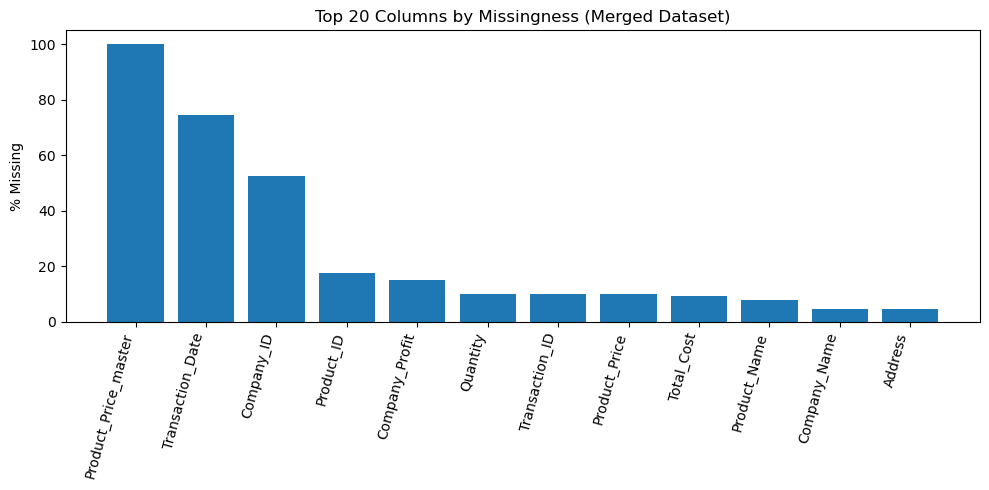

Top missing columns (%):
Product_Price_master    100.000000
Transaction_Date         74.362912
Company_ID               52.454768
Product_ID               17.632097
Company_Profit           15.179728
Quantity                 10.087825
Transaction_ID           10.030235
Product_Price            10.011038
Total_Cost                9.319960
Product_Name              7.875414
Company_Name              4.655181
Address                   4.655181
dtype: float64


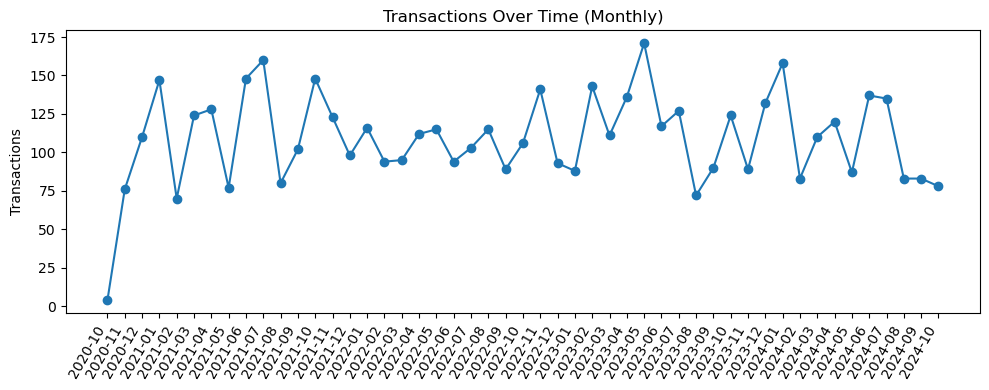

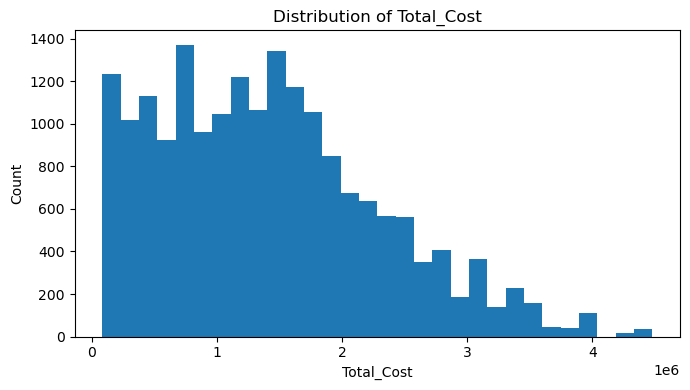

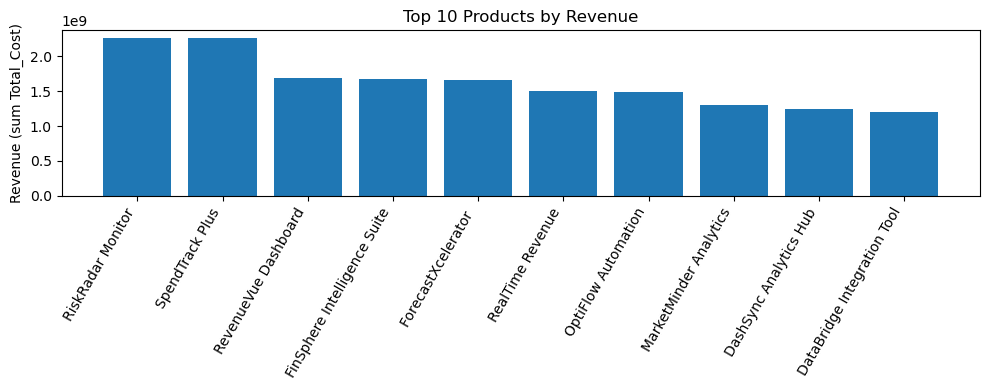

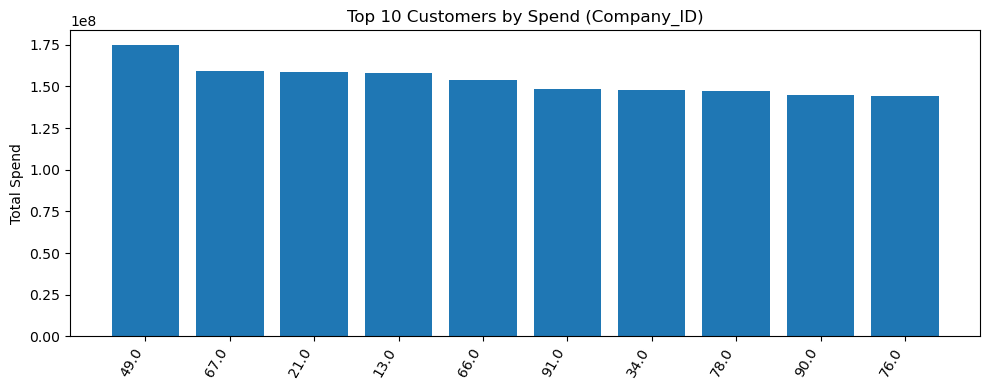


STEP 1: CLEAN + MERGE
------------------------------------------------------------------------------------------
We convert date/numeric fields and merge:
transactions ⨝ products (Product_ID) ⨝ customers (Company_ID)
Result: each transaction row contains product + customer attributes.

Merged shape: (20837, 12)
Merged columns: ['Transaction_ID', 'Company_ID', 'Product_ID', 'Quantity', 'Transaction_Date', 'Product_Price', 'Total_Cost', 'Product_Name', 'Product_Price_master', 'Company_Name', 'Company_Profit', 'Address']

Merged dataset meaning
------------------------------------------------------------------------------------------
Each row is a transaction enriched with product and customer data.
This is the integrated base for both EDA and feature engineering.



In [35]:
# ============================================================
# 2) QUICK EDA VISUALS
# ============================================================
explain(
    "STEP 2: EDA VISUALS",
    "We inspect missingness, spending distribution, timeline, and concentration (top products/customers)."
)

# A) Missingness (top 20)
missing_pct = (df.isna().mean().sort_values(ascending=False) * 100).head(20)
plt.figure(figsize=(10,5))
plt.bar(missing_pct.index.astype(str), missing_pct.values)
plt.xticks(rotation=75, ha="right")
plt.ylabel("% Missing")
plt.title("Top 20 Columns by Missingness (Merged Dataset)")
plt.tight_layout()
plt.show()
print("Top missing columns (%):")
print(missing_pct)

# B) Timeline
df_dates = df.dropna(subset=["Transaction_Date"]).copy()
if not df_dates.empty:
    df_dates["YearMonth"] = df_dates["Transaction_Date"].dt.to_period("M").astype(str)
    monthly = df_dates.groupby("YearMonth").size()
    plt.figure(figsize=(10,4))
    plt.plot(monthly.index, monthly.values, marker="o")
    plt.xticks(rotation=60, ha="right")
    plt.ylabel("Transactions")
    plt.title("Transactions Over Time (Monthly)")
    plt.tight_layout()
    plt.show()

# C) Total_Cost distribution
if "Total_Cost" in df.columns:
    safe_hist(df["Total_Cost"], "Distribution of Total_Cost", "Total_Cost", bins=30)

# D) Top products by revenue
if "Product_Name" in df.columns and "Total_Cost" in df.columns:
    top_prod = (df.dropna(subset=["Product_Name", "Total_Cost"])
                  .groupby("Product_Name")["Total_Cost"].sum()
                  .sort_values(ascending=False).head(10))
    if not top_prod.empty:
        plt.figure(figsize=(10,4))
        plt.bar(top_prod.index.astype(str), top_prod.values)
        plt.xticks(rotation=60, ha="right")
        plt.ylabel("Revenue (sum Total_Cost)")
        plt.title("Top 10 Products by Revenue")
        plt.tight_layout()
        plt.show()

# E) Top customers by spend
if "Company_ID" in df.columns and "Total_Cost" in df.columns:
    top_cust = (df.dropna(subset=["Company_ID", "Total_Cost"])
                  .groupby("Company_ID")["Total_Cost"].sum()
                  .sort_values(ascending=False).head(10))
    if not top_cust.empty:
        plt.figure(figsize=(10,4))
        plt.bar(top_cust.index.astype(str), top_cust.values)
        plt.xticks(rotation=60, ha="right")
        plt.ylabel("Total Spend")
        plt.title("Top 10 Customers by Spend (Company_ID)")
        plt.tight_layout()
        plt.show()

# ============================================================
# 1) CLEAN + MERGE
# ============================================================
explain(
    "STEP 1: CLEAN + MERGE",
    "We convert date/numeric fields and merge:\n"
    "transactions ⨝ products (Product_ID) ⨝ customers (Company_ID)\n"
    "Result: each transaction row contains product + customer attributes."
)

tx = tx.loc[:, ~tx.columns.str.contains("^Unnamed", case=False)].copy()

if "Transaction_Date" not in tx.columns:
    raise KeyError("transactions_data.csv must contain 'Transaction_Date'")

tx["Transaction_Date"] = pd.to_datetime(tx["Transaction_Date"], errors="coerce")

for c in ["Transaction_ID", "Company_ID", "Product_ID", "Quantity"]:
    if c in tx.columns:
        tx[c] = pd.to_numeric(tx[c], errors="coerce")

for c in ["Product_Price", "Total_Cost"]:
    if c in tx.columns:
        tx[c] = pd.to_numeric(tx[c], errors="coerce")

# products
if "Product_ID" not in pr.columns:
    raise KeyError("products_data.csv must contain 'Product_ID'")
pr = pr.copy()
pr["Product_ID"] = pd.to_numeric(pr["Product_ID"], errors="coerce")
if "Product_Price" in pr.columns:
    pr["Product_Price_master"] = pd.to_numeric(pr["Product_Price"], errors="coerce")
    pr = pr.drop(columns=["Product_Price"], errors="ignore")

# customers
if "Company_ID" not in cu.columns:
    raise KeyError("customers_data.csv must contain 'Company_ID'")
cu = cu.copy()
cu["Company_ID"] = pd.to_numeric(cu["Company_ID"], errors="coerce")
if "Company_Profit" in cu.columns:
    cu["Company_Profit"] = pd.to_numeric(cu["Company_Profit"], errors="coerce")
for c in ["Company_Name", "Address"]:
    if c in cu.columns:
        cu[c] = cu[c].astype(str).replace({"nan": np.nan, "None": np.nan})

# merge
if "Product_ID" not in tx.columns or "Company_ID" not in tx.columns:
    raise KeyError("transactions must contain both 'Product_ID' and 'Company_ID'")

df = tx.merge(pr, on="Product_ID", how="left").merge(cu, on="Company_ID", how="left")

print("Merged shape:", df.shape)
print("Merged columns:", list(df.columns))
explain(
    "Merged dataset meaning",
    "Each row is a transaction enriched with product and customer data.\n"
    "This is the integrated base for both EDA and feature engineering."
)



In [36]:
# ============================================================
# 3) BUILD CUSTOMER-LEVEL FEATURES + TARGET WINDOWS
# ============================================================
explain(
    "STEP 3: CUSTOMER-LEVEL FEATURES (RFM + Spend Indicators) + TIME WINDOWS",
    "We build features ONLY from history (before cutoff) to avoid data leakage.\n"
    "Then define future windows to create targets (repeat/churn/CLV/time-to-next)."
)

# Must have these for modeling
required = ["Company_ID", "Transaction_Date", "Total_Cost"]
for c in required:
    if c not in df.columns:
        raise KeyError(f"Missing required column: {c}")

df_model = df.dropna(subset=required).copy()
if df_model.empty:
    raise ValueError("No usable rows after filtering. Check Transaction_Date/Total_Cost missingness.")

# Cutoff (75th percentile)
cutoff = df_model["Transaction_Date"].quantile(0.75)

# History for features
history = df_model[df_model["Transaction_Date"] <= cutoff].copy()

# Future windows for targets
future_30 = df_model[(df_model["Transaction_Date"] > cutoff) & (df_model["Transaction_Date"] <= cutoff + pd.Timedelta(days=30))].copy()
future_90 = df_model[(df_model["Transaction_Date"] > cutoff) & (df_model["Transaction_Date"] <= cutoff + pd.Timedelta(days=90))].copy()

print("Cutoff:", cutoff)
print("History rows:", history.shape[0], "Future30 rows:", future_30.shape[0], "Future90 rows:", future_90.shape[0])

# gap features
history = history.sort_values(["Company_ID", "Transaction_Date"])
history["prev_date"] = history.groupby("Company_ID")["Transaction_Date"].shift(1)
history["gap_days"] = (history["Transaction_Date"] - history["prev_date"]).dt.days

# choose price col if present
price_col = None
if "Product_Price" in history.columns:
    price_col = "Product_Price"
elif "Product_Price_master" in history.columns:
    price_col = "Product_Price_master"

# aggregation dictionary (robust to missing cols)
agg_dict = {
    "transaction_count": ("Transaction_ID", "count") if "Transaction_ID" in history.columns else ("Total_Cost", "size"),
    "total_spend": ("Total_Cost", "sum"),
    "avg_order_value": ("Total_Cost", "mean"),
    "unique_products": ("Product_ID", "nunique"),
    "gap_days_mean": ("gap_days", "mean"),
    "gap_days_std": ("gap_days", "std"),
    "first_tx": ("Transaction_Date", "min"),
    "last_tx": ("Transaction_Date", "max"),
}
if "Quantity" in history.columns:
    agg_dict["total_quantity"] = ("Quantity", "sum")
    agg_dict["avg_quantity"] = ("Quantity", "mean")

if price_col:
    agg_dict["avg_product_price"] = (price_col, "mean")
    agg_dict["max_product_price"] = (price_col, "max")

cust_features = history.groupby("Company_ID").agg(**agg_dict)

# RFM derived
cust_features["recency_days"] = (cutoff - cust_features["last_tx"]).dt.days
cust_features["tenure_days"] = (cust_features["last_tx"] - cust_features["first_tx"]).dt.days
cust_features = cust_features.drop(columns=["first_tx", "last_tx"])

# Spend indicators (customer-level)
cust_features["avg_spend_per_month"] = cust_features["total_spend"] / (cust_features["tenure_days"] / 30 + 1)

# spend volatility from transaction std
spend_std = history.groupby("Company_ID")["Total_Cost"].std().rename("spend_std")
cust_features = cust_features.merge(spend_std, left_index=True, right_index=True, how="left")

cust_features["spend_volatility"] = cust_features["spend_std"] / cust_features["avg_order_value"]

# CLV proxy
cust_features["clv_proxy"] = cust_features["avg_order_value"] * cust_features["transaction_count"]

# spend growth rate (2nd half vs 1st half)
def spend_growth(group):
    g = group.sort_values("Transaction_Date")
    n = len(g)
    if n < 2:
        return np.nan
    half = n // 2
    first = g.iloc[:half]["Total_Cost"].mean()
    second = g.iloc[half:]["Total_Cost"].mean()
    return (second - first) / (first + 1)

growth = history.groupby("Company_ID").apply(spend_growth).rename("spend_growth_rate")
cust_features = cust_features.merge(growth, left_index=True, right_index=True, how="left")

# attach customer attributes
cust_attr_cols = ["Company_ID"]
for c in ["Company_Profit", "Address", "Company_Name"]:
    if c in cu.columns:
        cust_attr_cols.append(c)

cust_attrs = cu[cust_attr_cols].drop_duplicates("Company_ID").set_index("Company_ID")
dataset = cust_features.merge(cust_attrs, left_index=True, right_index=True, how="left")

print("Customer-level dataset shape:", dataset.shape)


STEP 3: CUSTOMER-LEVEL FEATURES (RFM + Spend Indicators) + TIME WINDOWS
------------------------------------------------------------------------------------------
We build features ONLY from history (before cutoff) to avoid data leakage.
Then define future windows to create targets (repeat/churn/CLV/time-to-next).

Cutoff: 2023-10-27 00:00:00
History rows: 1675 Future30 rows: 44 Future90 rows: 158
Customer-level dataset shape: (100, 20)


C:\Users\lawre\AppData\Local\Temp\ipykernel_19800\3123738318.py:94: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  growth = history.groupby("Company_ID").apply(spend_growth).rename("spend_growth_rate")


In [37]:
# ============================================================
# 4) TARGETS (repeat, churn, timing, CLV90, upsell)
# ============================================================
explain(
    "STEP 4: TARGET ENGINEERING",
    "We create multiple targets:\n"
    "- repeat_30d: bought again within 30 days after cutoff\n"
    "- churn_90d: did NOT buy within 90 days after cutoff\n"
    "- days_to_next_purchase: days until next purchase (regression)\n"
    "- future_90d_revenue: CLV-style target (regression)\n"
    "- upsell_flag: customer likely to increase spend (classification)"
)

# Repeat next 30 days (classification)
repeaters_30 = set(future_30["Company_ID"].unique())
dataset["repeat_30d"] = dataset.index.map(lambda cid: 1 if cid in repeaters_30 else 0)

# Churn next 90 days (classification): churn=1 if NOT active in next 90 days
active_90 = set(future_90["Company_ID"].unique())
dataset["churn_90d"] = dataset.index.map(lambda cid: 0 if cid in active_90 else 1)

# Next purchase timing (regression): days from cutoff to first purchase after cutoff
next_tx_after = (df_model[df_model["Transaction_Date"] > cutoff]
                 .groupby("Company_ID")["Transaction_Date"].min())
dataset["days_to_next_purchase"] = dataset.index.map(
    lambda cid: (next_tx_after.get(cid) - cutoff).days if cid in next_tx_after else np.nan
)

# CLV-style target: revenue in next 90 days
future_90_rev = future_90.groupby("Company_ID")["Total_Cost"].sum()
dataset["future_90d_revenue"] = dataset.index.map(lambda cid: float(future_90_rev.get(cid, 0.0)))

# Upsell propensity (classification): growth rate above threshold
dataset["upsell_flag"] = (pd.to_numeric(dataset["spend_growth_rate"], errors="coerce") > 0.20).astype(int)

# Revenue risk score (business metric): high spend + high churn probability (later)
# We'll compute risk after churn model produces probabilities.

print("Target distributions:")
print("repeat_30d:\n", dataset["repeat_30d"].value_counts(dropna=False))
print("churn_90d:\n", dataset["churn_90d"].value_counts(dropna=False))
print("upsell_flag:\n", dataset["upsell_flag"].value_counts(dropna=False))


STEP 4: TARGET ENGINEERING
------------------------------------------------------------------------------------------
We create multiple targets:
- repeat_30d: bought again within 30 days after cutoff
- churn_90d: did NOT buy within 90 days after cutoff
- days_to_next_purchase: days until next purchase (regression)
- future_90d_revenue: CLV-style target (regression)
- upsell_flag: customer likely to increase spend (classification)

Target distributions:
repeat_30d:
 repeat_30d
0    68
1    32
Name: count, dtype: int64
churn_90d:
 churn_90d
0    74
1    26
Name: count, dtype: int64
upsell_flag:
 upsell_flag
0    60
1    40
Name: count, dtype: int64



STEP 5: THESIS-READY VISUALS (RFM + Pareto + Segments)
------------------------------------------------------------------------------------------
These plots support your write-up: customer value distribution, revenue concentration, and repeat behavior by segment.



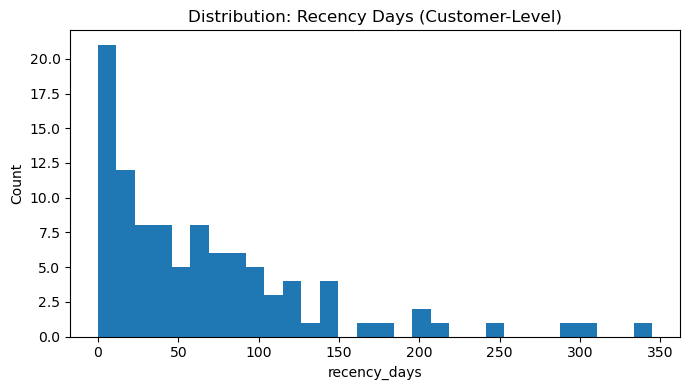

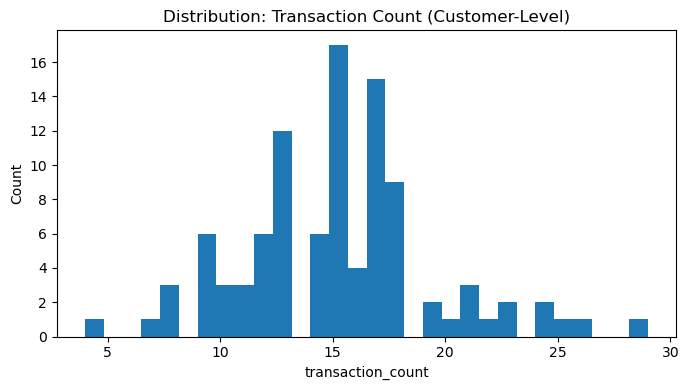

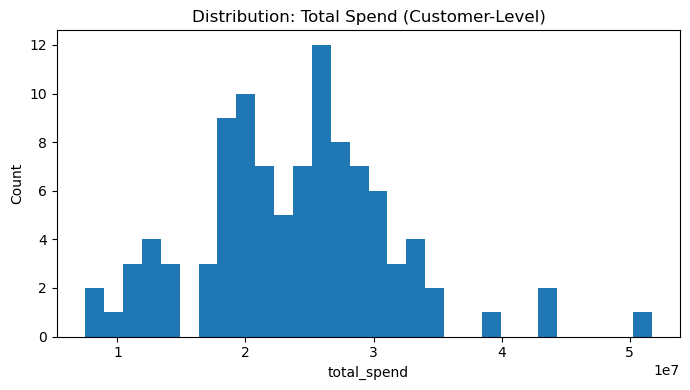

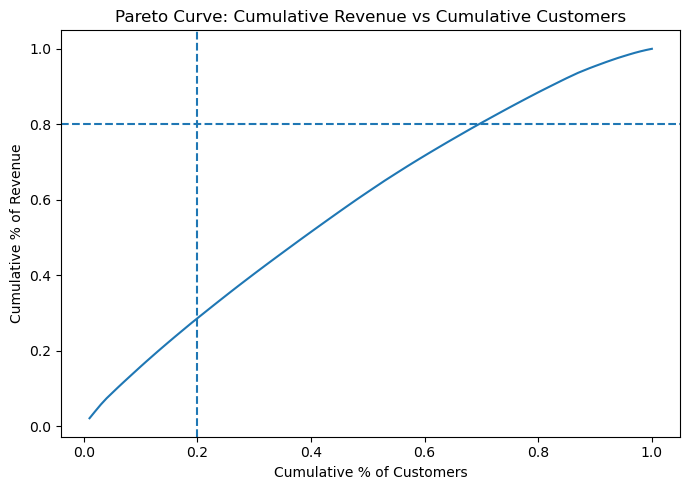

Approx. 70.0% of customers generate 80% of revenue.

Spend Segment Summary:
                customers  repeat_rate   avg_spend
spend_segment                                    
Low                   25         0.32  14824096.0
Medium                25         0.40  21465696.0
High                  25         0.24  26294016.0
Top                   25         0.32  33153120.0


C:\Users\lawre\AppData\Local\Temp\ipykernel_19800\4137565103.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seg = ds.groupby("spend_segment").agg(


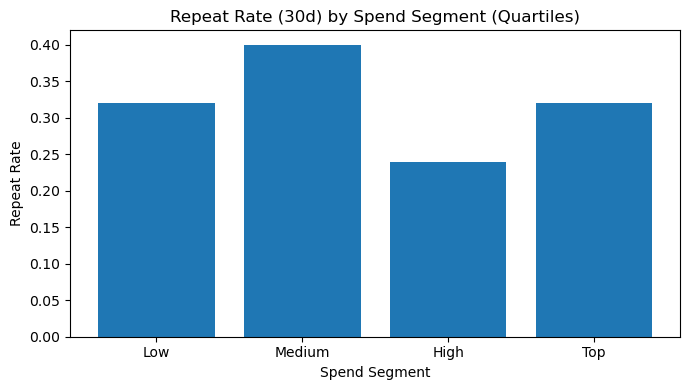

In [38]:
# ============================================================
# 5) VISUALIZE RFM + PARETO + SEGMENTS (thesis-ready)
# ============================================================
explain(
    "STEP 5: THESIS-READY VISUALS (RFM + Pareto + Segments)",
    "These plots support your write-up: customer value distribution, revenue concentration, and repeat behavior by segment."
)

# RFM distributions
for col in ["recency_days", "transaction_count", "total_spend"]:
    if col in dataset.columns:
        safe_hist(dataset[col], f"Distribution: {col.replace('_',' ').title()} (Customer-Level)", col)

# Pareto curve (fixed: no .iloc on numpy)
rev = pd.to_numeric(dataset["total_spend"], errors="coerce").dropna().sort_values(ascending=False)
if len(rev) > 0 and rev.sum() > 0:
    cum_rev = rev.cumsum() / rev.sum()
    cum_cust = np.arange(1, len(rev)+1) / len(rev)

    plt.figure(figsize=(7,5))
    plt.plot(cum_cust, cum_rev)
    plt.axhline(0.80, linestyle="--")
    plt.axvline(0.20, linestyle="--")
    plt.title("Pareto Curve: Cumulative Revenue vs Cumulative Customers")
    plt.xlabel("Cumulative % of Customers")
    plt.ylabel("Cumulative % of Revenue")
    plt.tight_layout()
    plt.show()

    percent_for_80 = cum_cust[(cum_rev.values >= 0.80)][0] * 100
    print(f"Approx. {percent_for_80:.1f}% of customers generate 80% of revenue.")

# Spend segments + repeat rate (repeat_30d)
ds = dataset.copy()
ds["total_spend_num"] = pd.to_numeric(ds["total_spend"], errors="coerce")
ds = ds.dropna(subset=["total_spend_num", "repeat_30d"])
if not ds.empty:
    ds["spend_segment"] = pd.qcut(ds["total_spend_num"], 4, labels=["Low", "Medium", "High", "Top"])
    seg = ds.groupby("spend_segment").agg(
        customers=("repeat_30d", "size"),
        repeat_rate=("repeat_30d", "mean"),
        avg_spend=("total_spend_num", "mean")
    )
    print("\nSpend Segment Summary:\n", seg)

    plt.figure(figsize=(7,4))
    plt.bar(seg.index.astype(str), seg["repeat_rate"].values)
    plt.title("Repeat Rate (30d) by Spend Segment (Quartiles)")
    plt.xlabel("Spend Segment")
    plt.ylabel("Repeat Rate")
    plt.tight_layout()
    plt.show()

In [39]:
# ============================================================
# 6) MODELING UTILITIES
# ============================================================
def build_preprocess(X):
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    preprocess = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), num_cols),
            ("cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=2)),
            ]), cat_cols),
        ],
        remainder="drop"
    )
    return preprocess, num_cols, cat_cols

def evaluate_classifier(name, clf, X_test, y_test, proba):
    pred05 = (proba >= 0.5).astype(int)
    best = best_threshold_for_f1(y_test, proba)
    pred_best = (proba >= best["threshold"]).astype(int)

    metrics = {
        "model": name,
        "roc_auc": roc_auc_score(y_test, proba),
        "pr_auc_ap": average_precision_score(y_test, proba),
        "accuracy@0.5": accuracy_score(y_test, pred05),
        "balanced_acc@0.5": balanced_accuracy_score(y_test, pred05),
        "precision@0.5": precision_score(y_test, pred05, zero_division=0),
        "recall@0.5": recall_score(y_test, pred05, zero_division=0),
        "f1@0.5": f1_score(y_test, pred05, zero_division=0),
        "best_f1": best["f1"],
        "best_f1_threshold": best["threshold"],
        "log_loss": log_loss(y_test, proba),
        "brier": brier_score_loss(y_test, proba),
        "lift@10%": lift_at_k(y_test, proba, 0.10)["lift"],
    }
    return metrics, best, pred_best



MODEL 1: REPEAT PURCHASE (30D) - CLASSIFICATION
------------------------------------------------------------------------------------------
We compare algorithms and report ROC-AUC, PR-AUC, F1, Lift@10%.

              model   roc_auc  pr_auc_ap  accuracy@0.5  balanced_acc@0.5  \
0            LogReg  0.419118   0.299681          0.52          0.382353   
2  GradientBoosting  0.397059   0.292447          0.60          0.474265   
1      RandomForest  0.216912   0.232392          0.68          0.500000   

   precision@0.5  recall@0.5    f1@0.5   best_f1  best_f1_threshold  log_loss  \
0           0.00       0.000  0.000000  0.484848               0.05  0.766355   
2           0.25       0.125  0.166667  0.400000               0.05  1.111015   
1           0.00       0.000  0.000000  0.484848               0.05  0.718818   

      brier  lift@10%  
0  0.269816       0.0  
2  0.342321       0.0  
1  0.252429       0.0  

Best Repeat Model: LogReg
Best threshold (F1): 0.05 Best F1: 0.48484

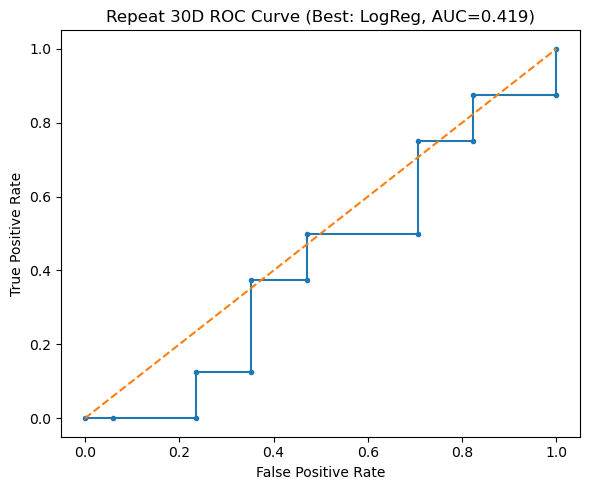

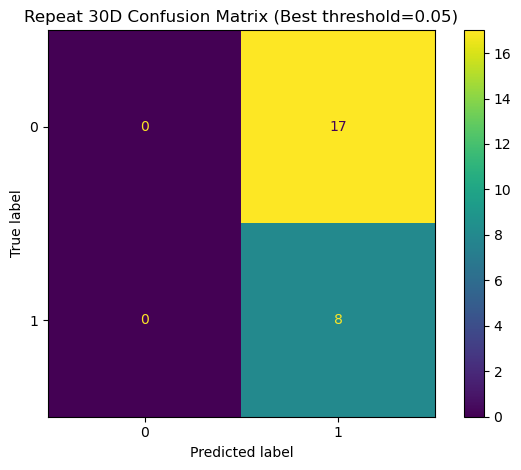

In [40]:
# ============================================================
# 7) CLASSIFICATION: Repeat Purchase (30d)
# ============================================================
explain(
    "MODEL 1: REPEAT PURCHASE (30D) - CLASSIFICATION",
    "We compare algorithms and report ROC-AUC, PR-AUC, F1, Lift@10%."
)

# Prepare data
target_col = "repeat_30d"
model_df = dataset.dropna(subset=[target_col]).copy()
X = model_df.drop(columns=[target_col, "churn_90d", "days_to_next_purchase", "future_90d_revenue", "upsell_flag"], errors="ignore")
y = model_df[target_col].astype(int)

# Ensure both classes exist
if y.nunique() < 2:
    raise ValueError(f"{target_col} has only one class. Adjust window/cutoff.")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
preprocess, num_cols, cat_cols = build_preprocess(X)

repeat_models = {
    "LogReg": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=400, random_state=42, class_weight="balanced_subsample"),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
}

repeat_results = []
repeat_fitted = {}

for name, model in repeat_models.items():
    clf = Pipeline(steps=[("preprocess", preprocess), ("model", model)])
    clf.fit(X_train, y_train)
    proba = clf.predict_proba(X_test)[:, 1]
    m, best, pred_best = evaluate_classifier(name, clf, X_test, y_test, proba)
    repeat_results.append(m)
    repeat_fitted[name] = (clf, proba, best, pred_best)

repeat_results_df = pd.DataFrame(repeat_results).sort_values(["pr_auc_ap", "roc_auc"], ascending=False)
print(repeat_results_df)

best_repeat_name = repeat_results_df.iloc[0]["model"]
best_repeat_clf, best_repeat_proba, best_repeat_best, best_repeat_pred_best = repeat_fitted[best_repeat_name]

print("\nBest Repeat Model:", best_repeat_name)
print("Best threshold (F1):", best_repeat_best["threshold"], "Best F1:", best_repeat_best["f1"])

# ROC curve for best repeat model
fpr, tpr, _ = roc_curve(y_test, best_repeat_proba)
auc = roc_auc_score(y_test, best_repeat_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, marker=".")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Repeat 30D ROC Curve (Best: {best_repeat_name}, AUC={auc:.3f})")
plt.tight_layout()
plt.show()

# Confusion matrix best threshold
cm = confusion_matrix(y_test, best_repeat_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title(f"Repeat 30D Confusion Matrix (Best threshold={best_repeat_best['threshold']:.2f})")
plt.tight_layout()
plt.show()


MODEL 2: CHURN (90D) - CLASSIFICATION
------------------------------------------------------------------------------------------
Target churn_90d: 1 = churned (no purchase in next 90 days), 0 = still active.

              model   roc_auc  pr_auc_ap  accuracy@0.5  balanced_acc@0.5  \
1      RandomForest  0.447368   0.295486          0.76          0.500000   
0            LogReg  0.429825   0.276766          0.40          0.320175   
2  GradientBoosting  0.333333   0.204226          0.64          0.421053   

   precision@0.5  recall@0.5    f1@0.5   best_f1  best_f1_threshold  log_loss  \
1       0.000000    0.000000  0.000000  0.387097               0.05  0.593336   
0       0.090909    0.166667  0.117647  0.400000               0.10  0.738371   
2       0.000000    0.000000  0.000000  0.285714               0.05  1.067633   

      brier  lift@10%  
1  0.196491  1.388889  
0  0.271181  1.388889  
2  0.309717  0.000000  

Best Churn Model: RandomForest
Best threshold (F1): 0.05 Best F

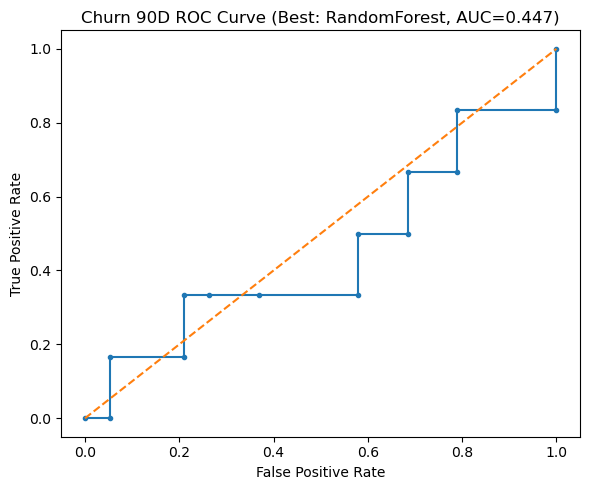

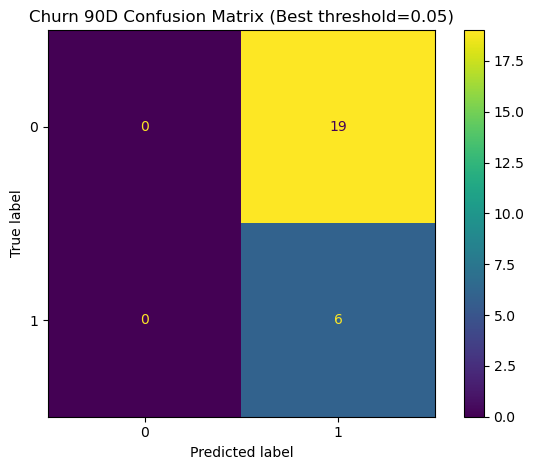

In [41]:
# ============================================================
# 8) CLASSIFICATION: Churn (90d)
# ============================================================
explain(
    "MODEL 2: CHURN (90D) - CLASSIFICATION",
    "Target churn_90d: 1 = churned (no purchase in next 90 days), 0 = still active."
)

target_col = "churn_90d"
model_df = dataset.dropna(subset=[target_col]).copy()
Xc = model_df.drop(columns=[target_col, "repeat_30d", "days_to_next_purchase", "future_90d_revenue", "upsell_flag"], errors="ignore")
yc = model_df[target_col].astype(int)

if yc.nunique() < 2:
    raise ValueError(f"{target_col} has only one class. Adjust window/cutoff.")

Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.25, random_state=42, stratify=yc)
preprocess_c, _, _ = build_preprocess(Xc)

churn_models = {
    "LogReg": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=400, random_state=42, class_weight="balanced_subsample"),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
}

churn_results = []
churn_fitted = {}

for name, model in churn_models.items():
    clf = Pipeline(steps=[("preprocess", preprocess_c), ("model", model)])
    clf.fit(Xc_train, yc_train)
    proba = clf.predict_proba(Xc_test)[:, 1]
    m, best, pred_best = evaluate_classifier(name, clf, Xc_test, yc_test, proba)
    churn_results.append(m)
    churn_fitted[name] = (clf, proba, best, pred_best)

churn_results_df = pd.DataFrame(churn_results).sort_values(["pr_auc_ap", "roc_auc"], ascending=False)
print(churn_results_df)

best_churn_name = churn_results_df.iloc[0]["model"]
best_churn_clf, best_churn_proba, best_churn_best, best_churn_pred_best = churn_fitted[best_churn_name]

print("\nBest Churn Model:", best_churn_name)
print("Best threshold (F1):", best_churn_best["threshold"], "Best F1:", best_churn_best["f1"])

# ROC curve best churn model
fpr, tpr, _ = roc_curve(yc_test, best_churn_proba)
auc = roc_auc_score(yc_test, best_churn_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, marker=".")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Churn 90D ROC Curve (Best: {best_churn_name}, AUC={auc:.3f})")
plt.tight_layout()
plt.show()

cm = confusion_matrix(yc_test, best_churn_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title(f"Churn 90D Confusion Matrix (Best threshold={best_churn_best['threshold']:.2f})")
plt.tight_layout()
plt.show()


REVENUE RISK SCORE
------------------------------------------------------------------------------------------
We estimate revenue risk using predicted churn probability:
risk = total_spend × P(churn)
This highlights high-value customers likely to churn.

Top 10 Revenue Risk Customers (by score):
            total_spend  p_churn_90d  revenue_risk_score
Company_ID                                              
21.0         43103200.0       0.7150          30818788.0
41.0         33062400.0       0.7925          26201952.0
31.0         31696000.0       0.7925          25119080.0
36.0         31628800.0       0.7550          23879744.0
44.0         28448000.0       0.7750          22047200.0
8.0          27955200.0       0.7700          21525504.0
71.0         30447200.0       0.7050          21465276.0
93.0         27434400.0       0.7300          20027112.0
17.0         25827200.0       0.7525          19434968.0
45.0         26448800.0       0.6800          17985184.0


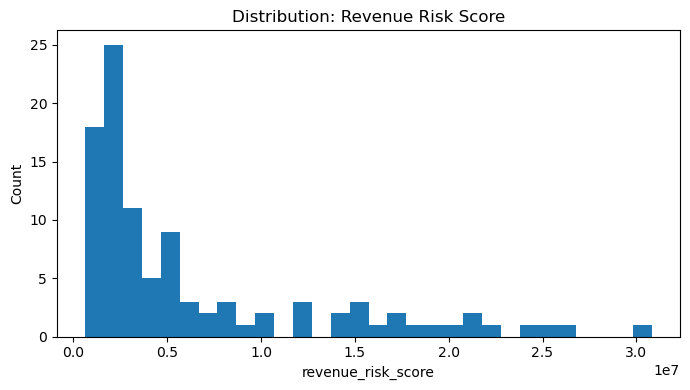

In [42]:
# ============================================================
# 9) REVENUE RISK SCORE (Business Metric)
# ============================================================
explain(
    "REVENUE RISK SCORE",
    "We estimate revenue risk using predicted churn probability:\n"
    "risk = total_spend × P(churn)\n"
    "This highlights high-value customers likely to churn."
)

# churn probability for ALL customers (use best churn model)
X_all = dataset.drop(columns=["churn_90d", "repeat_30d", "days_to_next_purchase", "future_90d_revenue", "upsell_flag"], errors="ignore")
churn_proba_all = best_churn_clf.predict_proba(X_all)[:, 1]
dataset["p_churn_90d"] = churn_proba_all
dataset["revenue_risk_score"] = pd.to_numeric(dataset["total_spend"], errors="coerce").fillna(0) * dataset["p_churn_90d"]

top_risk = dataset[["total_spend", "p_churn_90d", "revenue_risk_score"]].sort_values("revenue_risk_score", ascending=False).head(10)
print("Top 10 Revenue Risk Customers (by score):")
print(top_risk)

safe_hist(dataset["revenue_risk_score"], "Distribution: Revenue Risk Score", "revenue_risk_score", bins=30)


In [43]:
# ============================================================
# 10) REGRESSION: Next Purchase Timing (days)
# ============================================================
explain(
    "MODEL 3: NEXT PURCHASE TIMING (Regression)",
    "Target: days_to_next_purchase (for customers who actually purchased again).\n"
    "We train a regressor to estimate when the next purchase will happen."
)

reg_df = dataset.dropna(subset=["days_to_next_purchase"]).copy()
Xr = reg_df.drop(columns=["days_to_next_purchase", "repeat_30d", "churn_90d", "future_90d_revenue", "upsell_flag"], errors="ignore")
yr = reg_df["days_to_next_purchase"].astype(float)

if len(reg_df) < 20:
    print("Not enough rows for timing regression. Skipping.")
else:
    Xr_train, Xr_test, yr_train, yr_test = train_test_split(
        Xr, yr, test_size=0.25, random_state=42
    )
    preprocess_r, _, _ = build_preprocess(Xr)

    timing_models = {
        "RandomForestReg": RandomForestRegressor(n_estimators=400, random_state=42),
        "GradientBoostingReg": GradientBoostingRegressor(random_state=42),
    }

    timing_results = []
    for name, model in timing_models.items():
        reg = Pipeline(steps=[("preprocess", preprocess_r), ("model", model)])
        reg.fit(Xr_train, yr_train)
        pred = reg.predict(Xr_test)

        timing_results.append({
            "model": name,
            "MAE": mean_absolute_error(yr_test, pred),
            "RMSE": float(np.sqrt(mean_squared_error(yr_test, pred))),  # ✅ FIXED
            "R2": r2_score(yr_test, pred),
        })

    timing_results_df = pd.DataFrame(timing_results).sort_values("MAE")
    print(timing_results_df)



MODEL 3: NEXT PURCHASE TIMING (Regression)
------------------------------------------------------------------------------------------
Target: days_to_next_purchase (for customers who actually purchased again).
We train a regressor to estimate when the next purchase will happen.

                 model        MAE       RMSE        R2
0      RandomForestReg  35.436400  47.698199  0.476450
1  GradientBoostingReg  39.351641  52.965806  0.354427


In [44]:
# ============================================================
# 12) CLASSIFICATION: Upsell Propensity
# ============================================================
explain(
    "MODEL 5: UPSELL PROPENSITY - CLASSIFICATION",
    "Target: upsell_flag = 1 if spend_growth_rate > 20% (example rule).\n"
    "This predicts which customers are likely to increase spending."
)

u_df = dataset.dropna(subset=["upsell_flag"]).copy()
Xu = u_df.drop(columns=["upsell_flag", "repeat_30d", "churn_90d", "days_to_next_purchase", "future_90d_revenue"], errors="ignore")
yu = u_df["upsell_flag"].astype(int)

if yu.nunique() < 2:
    print("upsell_flag has only one class. Adjust threshold or definition.")
else:
    Xu_train, Xu_test, yu_train, yu_test = train_test_split(Xu, yu, test_size=0.25, random_state=42, stratify=yu)
    preprocess_u, _, _ = build_preprocess(Xu)

    upsell_models = {
        "LogReg": LogisticRegression(max_iter=2000, class_weight="balanced"),
        "RandomForest": RandomForestClassifier(n_estimators=400, random_state=42, class_weight="balanced_subsample"),
        "GradientBoosting": GradientBoostingClassifier(random_state=42),
    }

    upsell_results = []
    for name, model in upsell_models.items():
        clf = Pipeline(steps=[("preprocess", preprocess_u), ("model", model)])
        clf.fit(Xu_train, yu_train)
        proba = clf.predict_proba(Xu_test)[:, 1]
        metrics, best, pred_best = evaluate_classifier(name, clf, Xu_test, yu_test, proba)
        upsell_results.append(metrics)

    upsell_results_df = pd.DataFrame(upsell_results).sort_values(["pr_auc_ap", "roc_auc"], ascending=False)
    print(upsell_results_df)


MODEL 5: UPSELL PROPENSITY - CLASSIFICATION
------------------------------------------------------------------------------------------
Target: upsell_flag = 1 if spend_growth_rate > 20% (example rule).
This predicts which customers are likely to increase spending.

              model   roc_auc  pr_auc_ap  accuracy@0.5  balanced_acc@0.5  \
2  GradientBoosting  1.000000   1.000000          1.00          1.000000   
1      RandomForest  1.000000   1.000000          1.00          1.000000   
0            LogReg  0.946667   0.937374          0.88          0.866667   

   precision@0.5  recall@0.5    f1@0.5   best_f1  best_f1_threshold  log_loss  \
2       1.000000         1.0  1.000000  1.000000               0.05  0.000021   
1       1.000000         1.0  1.000000  1.000000               0.30  0.268787   
0       0.888889         0.8  0.842105  0.857143               0.40  0.328403   

          brier  lift@10%  
2  4.575637e-10       2.5  
1  6.211300e-02       2.5  
0  1.003429e-01    

In [45]:
# ============================================================
# 13) PRODUCT AFFINITY / MARKET BASKET (Optional: mlxtend)
# ============================================================
explain(
    "OPTIONAL MODULE: PRODUCT AFFINITY / MARKET BASKET",
    "If you have mlxtend installed, we can generate association rules\n"
    "to find product pairs frequently bought by the same customer."
)

try:
    from mlxtend.frequent_patterns import apriori, association_rules

    if "Product_Name" in df.columns:
        basket = (df.dropna(subset=["Company_ID", "Product_Name"])
                    .groupby(["Company_ID", "Product_Name"]).size()
                    .unstack(fill_value=0))

        # boolean basket
        basket_bool = basket > 0

        frequent = apriori(basket_bool, min_support=0.05, use_colnames=True)
        rules = association_rules(frequent, metric="confidence", min_threshold=0.5)

        # show top rules by lift
        rules_sorted = rules.sort_values("lift", ascending=False).head(10)
        print("Top 10 Association Rules (by lift):")
        print(rules_sorted[["antecedents", "consequents", "support", "confidence", "lift"]])

    else:
        print("Product_Name missing, cannot build basket by name. Use Product_ID instead if needed.")

except Exception as e:
    print("Market Basket skipped (mlxtend not installed or error).")
    print("Reason:", str(e))


OPTIONAL MODULE: PRODUCT AFFINITY / MARKET BASKET
------------------------------------------------------------------------------------------
If you have mlxtend installed, we can generate association rules
to find product pairs frequently bought by the same customer.

Market Basket skipped (mlxtend not installed or error).
Reason: No module named 'mlxtend'



OPTIONAL MODULE: REVENUE FORECASTING (Time Series)
------------------------------------------------------------------------------------------
We aggregate Total_Cost by month and forecast future months.
If statsmodels is available, we run ARIMA; otherwise we use a simple baseline forecast.



C:\Users\lawre\AppData\Local\Temp\ipykernel_19800\1026614037.py:26: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_rev = ts["Total_Cost"].resample("M").sum()


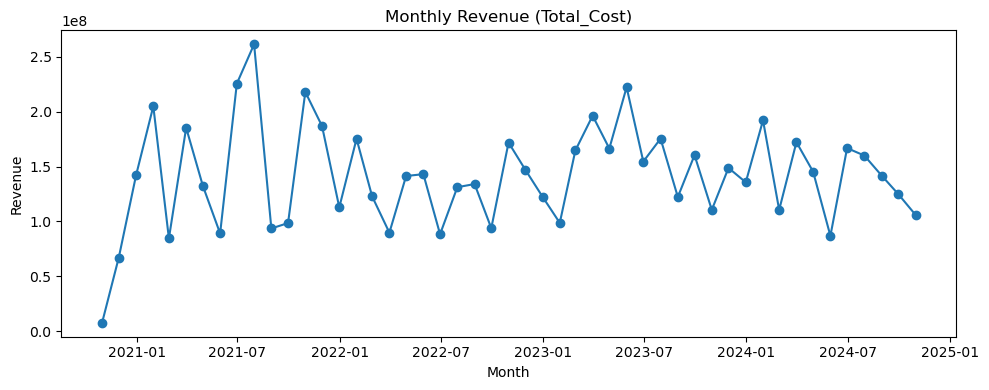


Forecast (next 3 months):
2024-11-30    1.300816e+08
2024-12-31    1.358383e+08
2025-01-31    1.372127e+08
Freq: ME, Name: predicted_mean, dtype: float64


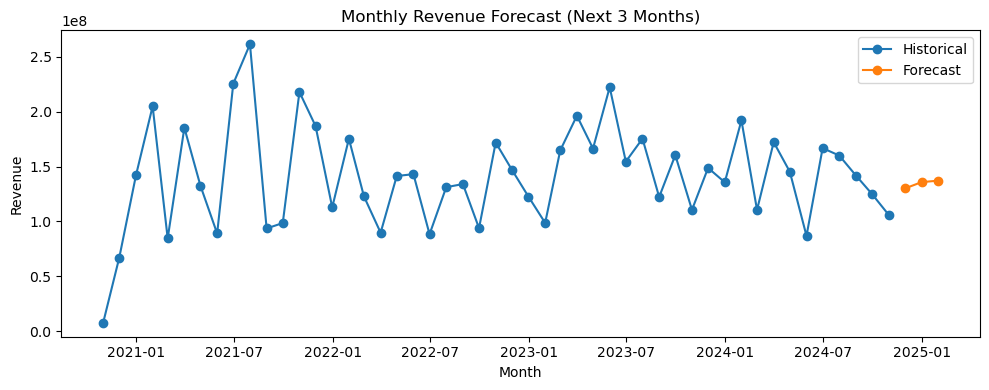

In [46]:
# ============================================================
# 15) REVENUE FORECASTING (Monthly) - SAFE VERSION
# ============================================================
explain(
    "OPTIONAL MODULE: REVENUE FORECASTING (Time Series)",
    "We aggregate Total_Cost by month and forecast future months.\n"
    "If statsmodels is available, we run ARIMA; otherwise we use a simple baseline forecast."
)

# --- Check required columns
if ("Transaction_Date" not in df.columns) or ("Total_Cost" not in df.columns):
    print("Skipping forecasting: missing Transaction_Date or Total_Cost.")
else:
    ts = df[["Transaction_Date", "Total_Cost"]].copy()

    # Ensure datetime + numeric
    ts["Transaction_Date"] = pd.to_datetime(ts["Transaction_Date"], errors="coerce")
    ts["Total_Cost"] = pd.to_numeric(ts["Total_Cost"], errors="coerce")

    ts = ts.dropna(subset=["Transaction_Date", "Total_Cost"])
    if ts.empty:
        print("Skipping forecasting: no valid rows after cleaning Transaction_Date/Total_Cost.")
    else:
        # Monthly revenue series
        ts = ts.sort_values("Transaction_Date").set_index("Transaction_Date")
        monthly_rev = ts["Total_Cost"].resample("M").sum()

        # Remove months with all-NaN (shouldn't happen after sum, but safe)
        monthly_rev = monthly_rev.dropna()

        if len(monthly_rev) < 3:
            print("Skipping forecasting: not enough monthly points (need at least 3).")
        else:
            # Plot historical monthly revenue
            plt.figure(figsize=(10,4))
            plt.plot(monthly_rev.index, monthly_rev.values, marker="o")
            plt.title("Monthly Revenue (Total_Cost)")
            plt.xlabel("Month")
            plt.ylabel("Revenue")
            plt.tight_layout()
            plt.show()

            # -----------------------------
            # Try ARIMA (if statsmodels installed)
            # -----------------------------
            forecast_steps = 3

            try:
                from statsmodels.tsa.arima.model import ARIMA

                # Need more data for stable ARIMA
                if len(monthly_rev) < 12:
                    print("Not enough months for reliable ARIMA (recommended >= 12). Using baseline forecast instead.")

                    # Baseline: average of last 3 months
                    last_k = min(3, len(monthly_rev))
                    baseline_value = monthly_rev.iloc[-last_k:].mean()

                    future_index = pd.date_range(
                        start=monthly_rev.index[-1] + pd.offsets.MonthEnd(1),
                        periods=forecast_steps,
                        freq="M"
                    )
                    forecast = pd.Series([baseline_value]*forecast_steps, index=future_index)

                else:
                    # ARIMA(1,1,1) basic
                    arima = ARIMA(monthly_rev, order=(1, 1, 1))
                    arima_fit = arima.fit()
                    forecast = arima_fit.forecast(steps=forecast_steps)

                print("\nForecast (next 3 months):")
                print(forecast)

                # Plot actual + forecast
                plt.figure(figsize=(10,4))
                plt.plot(monthly_rev.index, monthly_rev.values, marker="o", label="Historical")
                plt.plot(forecast.index, forecast.values, marker="o", label="Forecast")
                plt.title("Monthly Revenue Forecast (Next 3 Months)")
                plt.xlabel("Month")
                plt.ylabel("Revenue")
                plt.legend()
                plt.tight_layout()
                plt.show()

            except Exception as e:
                # -----------------------------
                # If ARIMA fails, use baseline forecast
                # -----------------------------
                print("ARIMA skipped (statsmodels not installed or error). Using baseline forecast.")
                print("Reason:", str(e))

                last_k = min(3, len(monthly_rev))
                baseline_value = monthly_rev.iloc[-last_k:].mean()

                future_index = pd.date_range(
                    start=monthly_rev.index[-1] + pd.offsets.MonthEnd(1),
                    periods=forecast_steps,
                    freq="M"
                )
                forecast = pd.Series([baseline_value]*forecast_steps, index=future_index)

                print("\nBaseline Forecast (next 3 months):")
                print(forecast)

                plt.figure(figsize=(10,4))
                plt.plot(monthly_rev.index, monthly_rev.values, marker="o", label="Historical")
                plt.plot(forecast.index, forecast.values, marker="o", label="Baseline Forecast")
                plt.title("Monthly Revenue Forecast (Baseline)")
                plt.xlabel("Month")
                plt.ylabel("Revenue")
                plt.legend()
                plt.tight_layout()
                plt.show()
